In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
# feedback dataset

feedback_data = [
    # Positive feedback
    ("The internship was excellent and I learned many new skills.", "Positive"),
    ("I really enjoyed working on real world projects.", "Positive"),
    ("The training sessions were very informative and helpful.", "Positive"),
    ("The mentor provided excellent guidance throughout the internship.", "Positive"),
    ("I gained valuable experience during this internship.", "Positive"),
    ("The projects helped me improve my programming skills.", "Positive"),
    ("The learning environment was supportive and friendly.", "Positive"),
    ("I learned a lot about artificial intelligence and machine learning.", "Positive"),
    ("The internship was a great opportunity to improve my technical skills.", "Positive"),
    ("The tasks were interesting and challenging in a good way.", "Positive"),
    ("My mentor was always available to answer my questions.", "Positive"),
    ("The internship improved my confidence in programming.", "Positive"),
    ("I enjoyed collaborating with other interns.", "Positive"),
    ("The practical assignments were very useful for learning.", "Positive"),
    ("The overall internship experience was amazing.", "Positive"),
    ("I developed several useful technical skills.", "Positive"),
    ("The sessions were well organized and easy to understand.", "Positive"),
    ("I am satisfied with the knowledge I gained.", "Positive"),
    ("The internship gave me useful industry exposure.", "Positive"),
    ("The staff was helpful and supportive.", "Positive"),
    ("I enjoyed every project assigned to me.", "Positive"),
    ("The feedback from my mentor helped me improve.", "Positive"),
    ("This internship was a valuable learning experience.", "Positive"),
    ("The training material was clear and useful.", "Positive"),
    ("I became more confident after completing the projects.", "Positive"),
    ("The internship exceeded my expectations.", "Positive"),
    ("The team created a positive learning environment.", "Positive"),
    ("I learned practical skills that I can use in my career.", "Positive"),
    ("The projects were creative and interesting.", "Positive"),
    ("Overall, I had a wonderful internship experience.", "Positive"),

    # Negative feedback
    ("The internship was disappointing and I learned very little.", "Negative"),
    ("The instructions were confusing and difficult to follow.", "Negative"),
    ("I did not receive enough guidance during the internship.", "Negative"),
    ("The tasks were repetitive and boring.", "Negative"),
    ("The mentor was rarely available to help.", "Negative"),
    ("The training sessions were poorly organized.", "Negative"),
    ("I struggled because there was not enough support.", "Negative"),
    ("The projects were not useful for improving my skills.", "Negative"),
    ("The learning material was confusing and incomplete.", "Negative"),
    ("I was unhappy with the overall internship experience.", "Negative"),
    ("The tasks were too difficult without proper guidance.", "Negative"),
    ("There was very little communication from the team.", "Negative"),
    ("The internship did not meet my expectations.", "Negative"),
    ("I did not learn many practical skills.", "Negative"),
    ("The sessions were boring and lacked useful information.", "Negative"),
    ("The project requirements were unclear.", "Negative"),
    ("I received very little feedback on my work.", "Negative"),
    ("The internship environment was stressful.", "Negative"),
    ("The assignments were repetitive and not challenging.", "Negative"),
    ("The mentor did not explain the concepts properly.", "Negative"),
    ("The training schedule was poorly managed.", "Negative"),
    ("I felt that my time was not used effectively.", "Negative"),
    ("The internship provided limited learning opportunities.", "Negative"),
    ("The instructions changed too frequently.", "Negative"),
    ("I was not satisfied with the support provided.", "Negative"),
    ("The projects did not seem relevant to my studies.", "Negative"),
    ("The overall experience was frustrating.", "Negative"),
    ("There were many communication problems.", "Negative"),
    ("The training content was outdated.", "Negative"),
    ("I expected much more from this internship.", "Negative"),

    # Neutral feedback
    ("The internship was okay and I learned some new things.", "Neutral"),
    ("The training sessions were average.", "Neutral"),
    ("The internship experience was neither good nor bad.", "Neutral"),
    ("The projects were reasonable and manageable.", "Neutral"),
    ("The mentor provided basic guidance.", "Neutral"),
    ("The tasks were simple and straightforward.", "Neutral"),
    ("The learning environment was acceptable.", "Neutral"),
    ("I learned a few useful skills during the internship.", "Neutral"),
    ("The internship met some of my expectations.", "Neutral"),
    ("The sessions were informative but could be improved.", "Neutral"),
    ("The workload was moderate.", "Neutral"),
    ("The projects were interesting to some extent.", "Neutral"),
    ("The training material was satisfactory.", "Neutral"),
    ("The internship provided some practical experience.", "Neutral"),
    ("The communication with the team was acceptable.", "Neutral"),
    ("The assignments were manageable.", "Neutral"),
    ("The mentor was available most of the time.", "Neutral"),
    ("The internship had both good and bad aspects.", "Neutral"),
    ("The overall experience was average.", "Neutral"),
    ("The projects were useful but not very challenging.", "Neutral"),
    ("The training schedule was reasonable.", "Neutral"),
    ("I gained some knowledge from the internship.", "Neutral"),
    ("The instructions were mostly clear.", "Neutral"),
    ("The experience was satisfactory overall.", "Neutral"),
    ("The internship was useful in some areas.", "Neutral"),
    ("The sessions were fairly organized.", "Neutral"),
    ("The tasks were neither too easy nor too difficult.", "Neutral"),
    ("The internship provided a moderate learning experience.", "Neutral"),
    ("The support from the team was acceptable.", "Neutral"),
    ("The internship could be improved in several areas.", "Neutral")
]

df = pd.DataFrame(feedback_data, columns=["feedback", "sentiment"])

print("Dataset created successfully!")
print("Number of records:", len(df))

df.head(10)

Dataset created successfully!
Number of records: 90


,feedback,sentiment
0,The internship was excellent and I learned man...,Positive
1,I really enjoyed working on real world projects.,Positive
2,The training sessions were very informative an...,Positive
3,The mentor provided excellent guidance through...,Positive
4,I gained valuable experience during this inter...,Positive
5,The projects helped me improve my programming ...,Positive
6,The learning environment was supportive and fr...,Positive
7,I learned a lot about artificial intelligence ...,Positive
8,The internship was a great opportunity to impr...,Positive
9,The tasks were interesting and challenging in ...,Positive


In [35]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Dataset Shape: (90, 2)

Column Names:
['feedback', 'sentiment']

Missing Values:
feedback     0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
Positive    30
Negative    30
Neutral     30
Name: count, dtype: int64


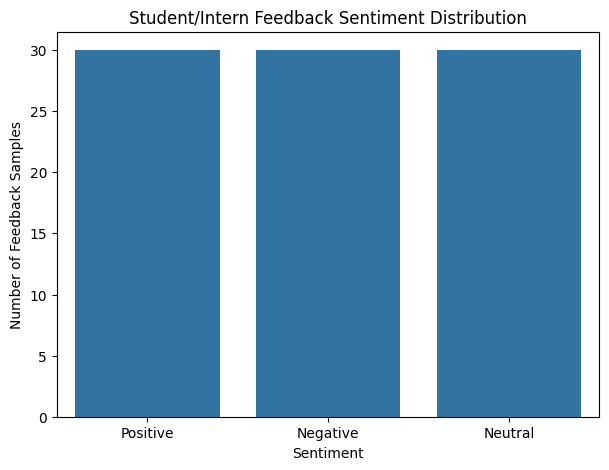

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Student/Intern Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback Samples")
plt.show()

In [37]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return tokens

df["tokens"] = df["feedback"].apply(preprocess_text)

df[["feedback", "tokens"]].head(10)

,feedback,tokens
0,The internship was excellent and I learned man...,"[internship, excellent, learned, many, new, sk..."
1,I really enjoyed working on real world projects.,"[really, enjoyed, working, real, world, projects]"
2,The training sessions were very informative an...,"[training, sessions, informative, helpful]"
3,The mentor provided excellent guidance through...,"[mentor, provided, excellent, guidance, throug..."
4,I gained valuable experience during this inter...,"[gained, valuable, experience, internship]"
5,The projects helped me improve my programming ...,"[projects, helped, improve, programming, skills]"
6,The learning environment was supportive and fr...,"[learning, environment, supportive, friendly]"
7,I learned a lot about artificial intelligence ...,"[learned, lot, artificial, intelligence, machi..."
8,The internship was a great opportunity to impr...,"[internship, great, opportunity, improve, tech..."
9,The tasks were interesting and challenging in ...,"[tasks, interesting, challenging, good, way]"


In [38]:
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

df[["feedback", "tokens", "clean_text", "sentiment"]].head(10)

,feedback,tokens,clean_text,sentiment
0,The internship was excellent and I learned man...,"[internship, excellent, learned, many, new, sk...",internship excellent learned many new skills,Positive
1,I really enjoyed working on real world projects.,"[really, enjoyed, working, real, world, projects]",really enjoyed working real world projects,Positive
2,The training sessions were very informative an...,"[training, sessions, informative, helpful]",training sessions informative helpful,Positive
3,The mentor provided excellent guidance through...,"[mentor, provided, excellent, guidance, throug...",mentor provided excellent guidance throughout ...,Positive
4,I gained valuable experience during this inter...,"[gained, valuable, experience, internship]",gained valuable experience internship,Positive
5,The projects helped me improve my programming ...,"[projects, helped, improve, programming, skills]",projects helped improve programming skills,Positive
6,The learning environment was supportive and fr...,"[learning, environment, supportive, friendly]",learning environment supportive friendly,Positive
7,I learned a lot about artificial intelligence ...,"[learned, lot, artificial, intelligence, machi...",learned lot artificial intelligence machine le...,Positive
8,The internship was a great opportunity to impr...,"[internship, great, opportunity, improve, tech...",internship great opportunity improve technical...,Positive
9,The tasks were interesting and challenging in ...,"[tasks, interesting, challenging, good, way]",tasks interesting challenging good way,Positive


In [39]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

print("TF-IDF matrix shape:", X.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

TF-IDF matrix shape: (90, 158)
Number of features: 158


In [40]:
feature_names = vectorizer.get_feature_names_out()

print("First 20 TF-IDF features:")
print(feature_names[:20])

First 20 TF-IDF features:
['acceptable' 'always' 'amazing' 'answer' 'areas' 'artificial' 'aspects'
 'assigned' 'assignments' 'available' 'average' 'bad' 'basic' 'became'
 'boring' 'career' 'challenging' 'changed' 'clear' 'collaborating']


In [41]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

tfidf_df.head()

,acceptable,always,amazing,answer,areas,artificial,aspects,assigned,assignments,available,...,useful,valuable,way,well,without,wonderful,work,working,workload,world
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.439527,0.0,0.439527
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.62161,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 72
Testing samples: 18


In [43]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [44]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Neutral' 'Negative' 'Negative' 'Neutral' 'Neutral' 'Neutral' 'Negative'
 'Negative' 'Positive' 'Negative' 'Negative' 'Positive' 'Negative'
 'Positive' 'Neutral' 'Negative' 'Positive' 'Negative']


In [45]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", round(accuracy * 100, 2), "%")

Test Accuracy: 0.4444444444444444
Test Accuracy (%): 44.44 %


In [46]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.44      0.67      0.53         6
     Neutral       0.40      0.33      0.36         6
    Positive       0.50      0.33      0.40         6

    accuracy                           0.44        18
   macro avg       0.45      0.44      0.43        18
weighted avg       0.45      0.44      0.43        18



In [47]:
# Improved TF-IDF Vectorization
# Using unigrams and bigrams

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

print("TF-IDF matrix shape:", X.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

TF-IDF matrix shape: (90, 389)
Number of features: 389


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 72
Testing samples: 18


In [49]:
model = LogisticRegression(
    max_iter=2000,
    C=2.0
)

model.fit(X_train, y_train)

print("Improved Logistic Regression model trained successfully!")

Improved Logistic Regression model trained successfully!


In [50]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Improved Test Accuracy:", accuracy)
print("Improved Test Accuracy (%):", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Improved Test Accuracy: 0.3333333333333333
Improved Test Accuracy (%): 33.33 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.33      0.50      0.40         6
     Neutral       0.29      0.33      0.31         6
    Positive       0.50      0.17      0.25         6

    accuracy                           0.33        18
   macro avg       0.37      0.33      0.32        18
weighted avg       0.37      0.33      0.32        18



In [51]:
# Add more realistic student/intern feedback

additional_feedback = [
    # Positive
    ("The mentor was supportive and helped me understand difficult concepts.", "Positive"),
    ("I gained practical experience by working on real projects.", "Positive"),
    ("The internship significantly improved my technical abilities.", "Positive"),
    ("The team was welcoming and encouraged me to ask questions.", "Positive"),
    ("I learned how to apply machine learning concepts in practice.", "Positive"),
    ("The training was engaging and easy to understand.", "Positive"),
    ("I received useful feedback that helped me improve my work.", "Positive"),
    ("The internship prepared me well for future career opportunities.", "Positive"),
    ("I enjoyed solving challenging problems during the internship.", "Positive"),
    ("The projects gave me a better understanding of industry practices.", "Positive"),
    ("My supervisor was helpful and provided clear explanations.", "Positive"),
    ("The internship was productive and educational.", "Positive"),
    ("I developed better problem solving skills during the training.", "Positive"),
    ("The practical work was much more useful than I expected.", "Positive"),
    ("I am happy with the knowledge and experience I gained.", "Positive"),
    ("The team provided excellent support whenever I needed help.", "Positive"),
    ("The internship helped me understand how professional teams work.", "Positive"),
    ("I found the assignments useful and relevant to my studies.", "Positive"),
    ("The overall training experience was very rewarding.", "Positive"),
    ("I would recommend this internship to other students.", "Positive"),
    ("The mentor explained everything clearly and patiently.", "Positive"),
    ("The projects improved both my technical and communication skills.", "Positive"),
    ("I felt motivated throughout the internship.", "Positive"),
    ("The internship gave me confidence to work on AI projects.", "Positive"),
    ("The learning resources were detailed and easy to follow.", "Positive"),
    ("I had a great opportunity to practice what I learned.", "Positive"),
    ("The team treated interns professionally and respectfully.", "Positive"),
    ("The internship was useful for understanding real industry problems.", "Positive"),
    ("I enjoyed learning new technologies during the internship.", "Positive"),
    ("The experience was valuable and exceeded my expectations.", "Positive"),

    # Negative
    ("The mentor did not provide enough help when I needed it.", "Negative"),
    ("I found the training sessions difficult to understand.", "Negative"),
    ("The internship lacked proper organization and planning.", "Negative"),
    ("The projects were unrelated to what I wanted to learn.", "Negative"),
    ("I received almost no feedback on my assignments.", "Negative"),
    ("The learning resources were incomplete and confusing.", "Negative"),
    ("There was not enough practical work during the internship.", "Negative"),
    ("The team did not communicate important information clearly.", "Negative"),
    ("I felt unsupported throughout most of the internship.", "Negative"),
    ("The training did not improve my technical skills.", "Negative"),
    ("The workload was poorly managed by the team.", "Negative"),
    ("The assignments were frustrating and unclear.", "Negative"),
    ("My questions were often left unanswered.", "Negative"),
    ("The internship was poorly structured from the beginning.", "Negative"),
    ("The sessions contained too much information without explanation.", "Negative"),
    ("I did not get enough opportunities to work on projects.", "Negative"),
    ("The instructions were inconsistent and confusing.", "Negative"),
    ("The experience was stressful and poorly managed.", "Negative"),
    ("The mentor rarely checked my progress.", "Negative"),
    ("The projects felt meaningless and repetitive.", "Negative"),
    ("The internship offered very limited practical learning.", "Negative"),
    ("The training materials were difficult to understand.", "Negative"),
    ("I was disappointed by the lack of support.", "Negative"),
    ("The schedule was disorganized and difficult to manage.", "Negative"),
    ("The team provided unclear requirements for the projects.", "Negative"),
    ("I expected more guidance from the mentor.", "Negative"),
    ("The internship did not provide useful industry experience.", "Negative"),
    ("The training environment was not motivating.", "Negative"),
    ("I struggled because the instructions were incomplete.", "Negative"),
    ("The overall internship experience was disappointing.", "Negative"),

    # Neutral
    ("The internship provided a reasonable amount of learning.", "Neutral"),
    ("The mentor gave basic instructions for each task.", "Neutral"),
    ("The training sessions covered the required topics.", "Neutral"),
    ("The projects were suitable for my current skill level.", "Neutral"),
    ("The internship experience was fairly standard.", "Neutral"),
    ("The workload was manageable throughout the internship.", "Neutral"),
    ("The team communicated with me when necessary.", "Neutral"),
    ("The training material covered the basic concepts.", "Neutral"),
    ("I completed most of the assigned tasks successfully.", "Neutral"),
    ("The internship provided some useful practical experience.", "Neutral"),
    ("The projects required a moderate level of effort.", "Neutral"),
    ("The mentor answered most of my questions.", "Neutral"),
    ("The training sessions were neither too difficult nor too easy.", "Neutral"),
    ("The experience was acceptable overall.", "Neutral"),
    ("The internship gave me a general idea of industry work.", "Neutral"),
    ("The assignments were appropriate for the training program.", "Neutral"),
    ("The team support was adequate.", "Neutral"),
    ("The projects were useful but could have been more challenging.", "Neutral"),
    ("The training followed a reasonable schedule.", "Neutral"),
    ("I gained some technical knowledge during the internship.", "Neutral"),
    ("The instructions were adequate for completing the tasks.", "Neutral"),
    ("The internship was satisfactory but not exceptional.", "Neutral"),
    ("The sessions provided a basic understanding of the topics.", "Neutral"),
    ("The overall experience was acceptable.", "Neutral"),
    ("The workload remained moderate throughout the program.", "Neutral"),
    ("The mentor provided guidance when requested.", "Neutral"),
    ("The projects were related to my field of study.", "Neutral"),
    ("The internship provided an average learning experience.", "Neutral"),
    ("The training was useful in some areas.", "Neutral"),
    ("The program met the basic requirements.", "Neutral")
]

# Convert additional data to DataFrame
additional_df = pd.DataFrame(
    additional_feedback,
    columns=["feedback", "sentiment"]
)

# Combine with original dataset
df = pd.concat([df[["feedback", "sentiment"]], additional_df],
               ignore_index=True)

print("Expanded dataset shape:", df.shape)
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Expanded dataset shape: (180, 2)

Sentiment distribution:
sentiment
Positive    60
Negative    60
Neutral     60
Name: count, dtype: int64


In [52]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return tokens

df["tokens"] = df["feedback"].apply(preprocess_text)

df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

df[["feedback", "tokens", "clean_text", "sentiment"]].head(10)

,feedback,tokens,clean_text,sentiment
0,The internship was excellent and I learned man...,"[internship, excellent, learned, many, new, sk...",internship excellent learned many new skills,Positive
1,I really enjoyed working on real world projects.,"[really, enjoyed, working, real, world, projects]",really enjoyed working real world projects,Positive
2,The training sessions were very informative an...,"[training, sessions, informative, helpful]",training sessions informative helpful,Positive
3,The mentor provided excellent guidance through...,"[mentor, provided, excellent, guidance, throug...",mentor provided excellent guidance throughout ...,Positive
4,I gained valuable experience during this inter...,"[gained, valuable, experience, internship]",gained valuable experience internship,Positive
5,The projects helped me improve my programming ...,"[projects, helped, improve, programming, skills]",projects helped improve programming skills,Positive
6,The learning environment was supportive and fr...,"[learning, environment, supportive, friendly]",learning environment supportive friendly,Positive
7,I learned a lot about artificial intelligence ...,"[learned, lot, artificial, intelligence, machi...",learned lot artificial intelligence machine le...,Positive
8,The internship was a great opportunity to impr...,"[internship, great, opportunity, improve, tech...",internship great opportunity improve technical...,Positive
9,The tasks were interesting and challenging in ...,"[tasks, interesting, challenging, good, way]",tasks interesting challenging good way,Positive


In [53]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

print("TF-IDF matrix shape:", X.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

TF-IDF matrix shape: (180, 752)
Number of features: 752


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 144
Testing samples: 36


In [55]:
model = LogisticRegression(
    max_iter=2000,
    C=2.0
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [56]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.5555555555555556
Test Accuracy (%): 55.56 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.42      0.50        12
     Neutral       0.50      0.58      0.54        12
    Positive       0.57      0.67      0.62        12

    accuracy                           0.56        36
   macro avg       0.57      0.56      0.55        36
weighted avg       0.57      0.56      0.55        36



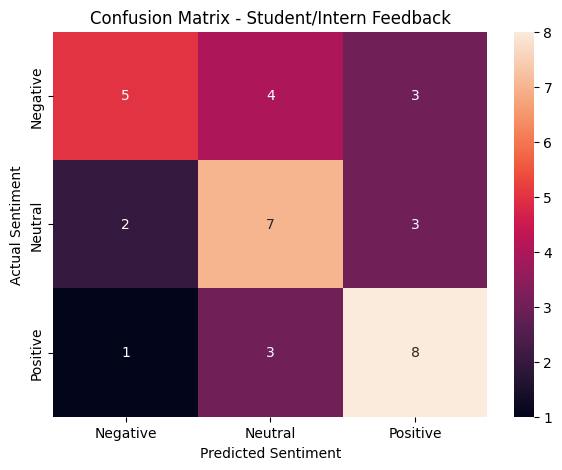

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix - Student/Intern Feedback")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [58]:
# Sample input/output predictions

sample_feedback = [
    "The mentor was extremely helpful and the internship taught me valuable skills.",
    "The training was poorly organized and I received almost no guidance.",
    "The internship was okay and provided some useful experience."
]

# Preprocess new feedback
sample_clean = [
    " ".join(preprocess_text(text))
    for text in sample_feedback
]

# Convert to TF-IDF
sample_vectors = vectorizer.transform(sample_clean)

# Predict sentiment
sample_predictions = model.predict(sample_vectors)

# Create results table
results = pd.DataFrame({
    "Sample Feedback": sample_feedback,
    "Predicted Sentiment": sample_predictions
})

results

,Sample Feedback,Predicted Sentiment
0,The mentor was extremely helpful and the inter...,Positive
1,The training was poorly organized and I receiv...,Negative
2,The internship was okay and provided some usef...,Neutral


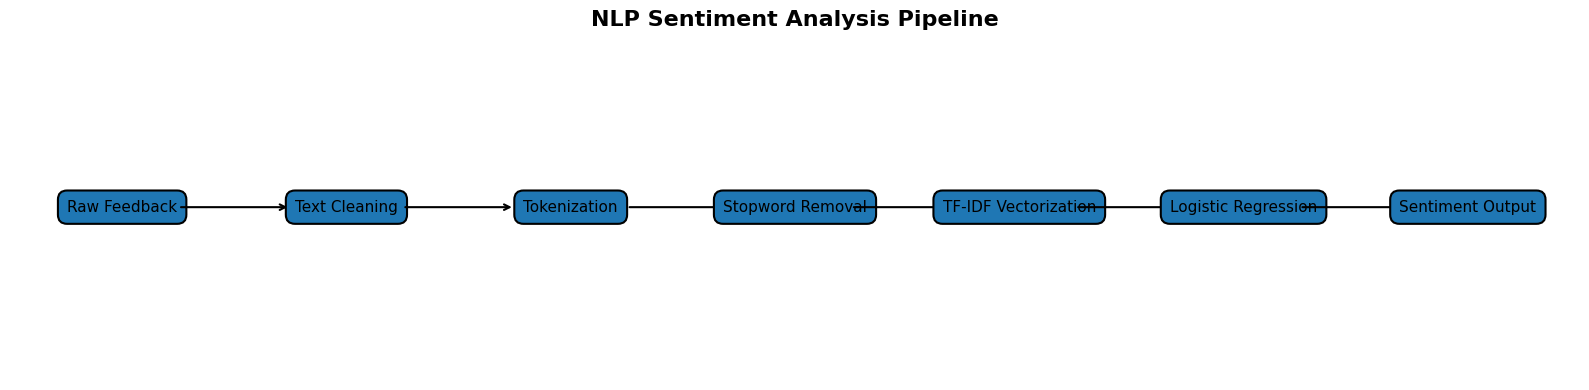

In [59]:
# NLP Pipeline Visualization

steps = [
    "Raw Feedback",
    "Text Cleaning",
    "Tokenization",
    "Stopword Removal",
    "TF-IDF Vectorization",
    "Logistic Regression",
    "Sentiment Output"
]

fig, ax = plt.subplots(figsize=(16, 4))

for i, step in enumerate(steps):
    ax.text(
        i,
        0,
        step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.6",
            edgecolor="black",
            linewidth=1.5
        )
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(i + 0.75, 0),
            xytext=(i + 0.25, 0),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5
            )
        )

ax.set_xlim(-0.5, len(steps) - 0.5)
ax.set_ylim(-0.7, 0.7)
ax.axis("off")

plt.title(
    "NLP Sentiment Analysis Pipeline",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# **Approach**
This project uses NLP to analyze intern feedback. The text is cleaned, tokenized, and stopwords are removed using NLTK. TF-IDF converts the text into numbers. The data is split into training and testing sets, and a Logistic Regression model is trained. The model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Finally, new feedback is given to the model to predict its sentiment.